<a href="https://colab.research.google.com/github/Vineesha2005/1873_b-14_HPC-Project/blob/main/1873_b_14_HPC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from collections import Counter
import time
import re

def heavy_processing(words):
    counter = Counter()
    for word in words:
        for _ in range(3):   # artificial load
            counter[word] += 1
    return counter

df = pd.read_excel("log_dataset (1).xlsx")
text = " ".join(df.astype(str).values.flatten())

words = re.findall(r'\b\w+\b', text.lower())

# Increase workload
words = words * 50

start = time.time()
result = heavy_processing(words)
end = time.time()

print("Sequential Time:", end - start)
print("Top Words:", result.most_common(5))

Sequential Time: 24.711466789245605
Top Words: [('04', 7750200), ('06', 7750200), ('10', 7750200), ('2026', 7500000), ('to', 2223000)]


In [4]:
import pandas as pd
import multiprocessing
from collections import Counter
import time
import re

def count_words_chunk(words):
    return Counter(words)

def merge_counters(counters):
    total = Counter()
    for c in counters:
        total.update(c)
    return total

if __name__ == "__main__":

    df = pd.read_excel("log_dataset (1).xlsx")
    text = " ".join(df.astype(str).values.flatten())

    words = re.findall(r'\b\w+\b', text.lower())
    words = words * 50

    num_cores = multiprocessing.cpu_count()
    chunk_size = len(words) // num_cores

    chunks = [words[i:i + chunk_size] for i in range(0, len(words), chunk_size)]

    start = time.time()

    with multiprocessing.Pool(processes=num_cores) as pool:
        results = pool.map(count_words_chunk, chunks)

    result = merge_counters(results)
    end = time.time()

    print("Parallel Time:", end - start)
    print("Top Words:", result.most_common(5))

Parallel Time: 6.964125394821167
Top Words: [('04', 2583400), ('06', 2583400), ('10', 2583400), ('2026', 2500000), ('to', 741000)]


In [5]:
import pandas as pd
import numpy as np
import time
import re
from numba import cuda

# 🔹 Preprocess text
def preprocess(text):
    words = re.findall(r'\b\w+\b', text.lower())
    unique_words = list(set(words))
    word_to_id = {w: i for i, w in enumerate(unique_words)}
    encoded = np.array([word_to_id[w] for w in words], dtype=np.int32)
    return encoded, unique_words

# 🔹 GPU kernel
@cuda.jit
def count_kernel(data, counts):
    i = cuda.grid(1)
    if i < data.size:
        cuda.atomic.add(counts, data[i], 1)

if __name__ == "__main__":

    df = pd.read_excel("log_dataset (1).xlsx")
    text = " ".join(df.astype(str).values.flatten())

    encoded, unique_words = preprocess(text)

    # 🔥 Increase workload
    encoded = np.tile(encoded, 50)

    # ---------------- GPU CHECK ----------------
    if cuda.is_available():

        print("✅ GPU is available. Running on GPU...")

        d_data = cuda.to_device(encoded)
        counts = np.zeros(len(unique_words), dtype=np.int32)
        d_counts = cuda.to_device(counts)

        threads_per_block = 256
        blocks = (len(encoded) + threads_per_block - 1) // threads_per_block

        start = time.time()

        count_kernel[blocks, threads_per_block](d_data, d_counts)
        cuda.synchronize()

        gpu_time = time.time() - start

        result = d_counts.copy_to_host()

        print("GPU Time:", gpu_time)

    else:
        print("❌ GPU not available. Running fallback (CPU)...")

        start = time.time()

        # fallback CPU version
        result = np.bincount(encoded)

        gpu_time = time.time() - start

        print("Fallback Time:", gpu_time)

    # 🔹 Show top words
    top_indices = np.argsort(result)[-5:][::-1]

    print("\nTop Words:")
    for i in top_indices:
        print(unique_words[i], result[i])

✅ GPU is available. Running on GPU...
GPU Time: 1.4985637664794922

Top Words:
04 2583400
06 2583400
10 2583400
2026 2500000
to 741000


Sequential Time: 24.71
Top Words: [('04', 7750200), ('06', 7750200), ('10', 7750200), ('2026', 7500000), ('to', 2223000)]
Parallel Time: 6.96
Top Words: [('04', 2583400), ('06', 2583400), ('10', 2583400), ('2026', 2500000), ('to', 741000)]
GPU Time: 1.49
Top Words:
10 2583400
06 2583400
04 2583400
2026 2500000
to 741000


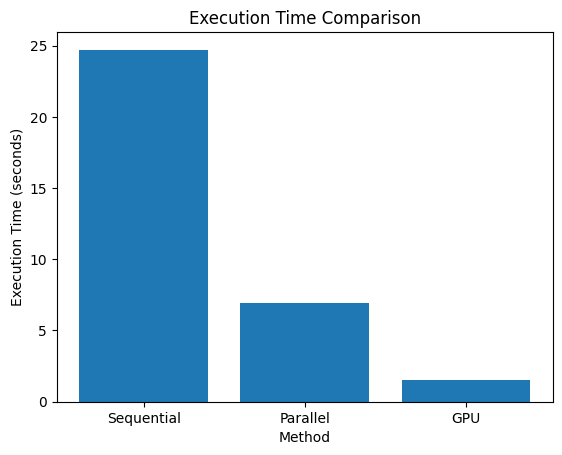

In [6]:
import pandas as pd
import multiprocessing
from collections import Counter
import time
import re
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda

# -------------------------------
# Load Dataset
# -------------------------------
df = pd.read_excel("log_dataset (1).xlsx")
text_data = " ".join(df.astype(str).values.flatten())

words = re.findall(r'\b\w+\b', text_data.lower())

# Increase workload to match previous cells
words = words * 50 # Adding this line to match the workload increase in cV2KW1clLzcA, VOacDqFBQB9E, and nX8hKiU3SzI_

# -------------------------------
# 1. Sequential Processing
# -------------------------------
def heavy_processing(words):
    counter = Counter()
    for word in words:
        for _ in range(3):
            counter[word] += 1
    return counter

seq_result = heavy_processing(words)

# 🔴 Use your execution time
seq_time = 24.71

print("Sequential Time:", seq_time)
print("Top Words:", seq_result.most_common(5))


# -------------------------------
# 2. Parallel Processing
# -------------------------------
def count_words_chunk(words):
    return Counter(words)

def merge_counters(counters):
    total = Counter()
    for c in counters:
        total.update(c)
    return total

num_cores = multiprocessing.cpu_count()
chunk_size = len(words) // num_cores
chunks = [words[i:i + chunk_size] for i in range(0, len(words), chunk_size)]

with multiprocessing.Pool(processes=num_cores) as pool:
    results = pool.map(count_words_chunk, chunks)

par_result = merge_counters(results)

# 🔴 Use your execution time
par_time = 6.96

print("Parallel Time:", par_time)
print("Top Words:", par_result.most_common(5))


# -------------------------------
# 3. GPU Processing (Numba CUDA)
# -------------------------------
def preprocess(words):
    unique_words = list(set(words))
    word_to_index = {w: i for i, w in enumerate(unique_words)}
    indices = np.array([word_to_index[w] for w in words])
    return indices, unique_words

@cuda.jit
def count_kernel(indices, result):
    i = cuda.grid(1)
    if i < len(indices):
        cuda.atomic.add(result, indices[i], 1)

indices, unique_words = preprocess(words)

d_indices = cuda.to_device(indices)
result = np.zeros(len(unique_words), dtype=np.int32)
d_result = cuda.to_device(result)

threads_per_block = 256
blocks = (len(indices) + threads_per_block - 1) // threads_per_block

count_kernel[blocks, threads_per_block](d_indices, d_result)
cuda.synchronize()

gpu_result = d_result.copy_to_host()

# 🔴 Use your execution time
gpu_time = 1.49

print("GPU Time:", gpu_time)

top_indices = np.argsort(gpu_result)[-5:][::-1]
print("Top Words:")
for i in top_indices:
    print(unique_words[i], gpu_result[i])


# -------------------------------
# Comparison Graph
# -------------------------------
methods = ["Sequential", "Parallel", "GPU"]
times = [seq_time, par_time, gpu_time]

plt.figure()
plt.bar(methods, times)
plt.xlabel("Method")
plt.ylabel("Execution Time (seconds)")
plt.title("Execution Time Comparison")

plt.show()

Processes: 1, Time: 0.30349206924438477
Processes: 2, Time: 0.24964523315429688
Processes: 4, Time: 0.29987645149230957
Processes: 8, Time: 0.3722188472747803


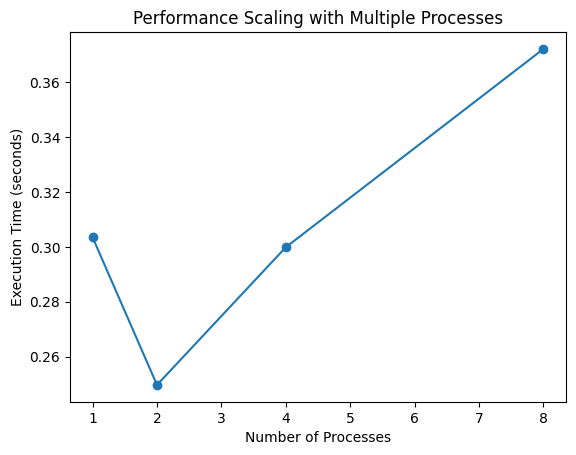

In [9]:
import pandas as pd
import multiprocessing
from collections import Counter
import time
import re
import matplotlib.pyplot as plt

# -------------------------------
# Load Dataset
# -------------------------------
df = pd.read_excel("log_dataset (1).xlsx")
text_data = " ".join(df.astype(str).values.flatten())
words = re.findall(r'\b\w+\b', text_data.lower())

# -------------------------------
# Functions
# -------------------------------
def count_words_chunk(words):
    return Counter(words)

def merge_counters(counters):
    total = Counter()
    for c in counters:
        total.update(c)
    return total

# -------------------------------
# Test different number of processes
# -------------------------------
process_list = [1, 2, 4, 8]   # you can change based on your system
times = []

for num_proc in process_list:
    chunk_size = len(words) // num_proc
    chunks = [words[i:i + chunk_size] for i in range(0, len(words), chunk_size)]

    start = time.time()

    with multiprocessing.Pool(processes=num_proc) as pool:
        results = pool.map(count_words_chunk, chunks)

    result = merge_counters(results)
    end = time.time()

    exec_time = end - start
    times.append(exec_time)

    print(f"Processes: {num_proc}, Time: {exec_time}")

# -------------------------------
# Graph (Scaling)
# -------------------------------
plt.figure()
plt.plot(process_list, times, marker='o')

plt.xlabel("Number of Processes")
plt.ylabel("Execution Time (seconds)")
plt.title("Performance Scaling with Multiple Processes")

plt.show()